# Model Compression of Denoising Diffusion Probabilistic Models (DDPM) using U-Net Backbone

### Team – Optimisers
### Team members:
1. Harini Sri Babu - 125100066
2. Dhanush Kumaar Haridas - 125102072
3. Dinesh Bhaskar - 125116090
4. John Tenis Johnson - 125103615
5. Arunrahul Selvakumar - 125103010

This project focuses on implementing a DDPM from scratch using a U-Net backbone and
systematically applying multiple model compression techniques to reduce model size and inference cost while maintaining acceptable generative performance.

## Key Concepts Explained

### What are Diffusion Models?


**Denoising Diffusion Probabilistic Models** (DDPM) is a generative model that creates new images through a two-phase process:

#### 1. **Forward Process (Diffusion)** 
- Gradually adds Gaussian noise to real images over many timesteps
- Starts with a clean image, ends with pure random noise

#### 2. **Reverse Process (Denoising)**
- A learned neural network learns to **reverse** the diffusion process
- Removes noise step-by-step from random noise
- Gradually transforms random noise into structured images
- This is what we **train** the model to do

### The Mathematical Foundation

#### Forward Process Equation

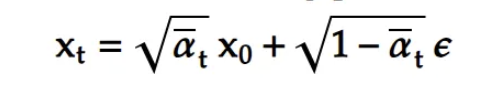

Where:
- x_t = Noisy image at timestep t
- x₀ = Original clean image  
- ᾱ_t = Cumulative product of alphas (decreasing over time)
- ε = Random Gaussian noise sampled from N(0, I)

| Term | Formula | Meaning |
|------|---------|---------|
| `β_t` | 0.0001 to 0.02 | Amount of noise added at timestep t |
| `α_t` | `1 - β_t` | Fraction of signal remaining at t |
| `ᾱ_t` | Product of all α | Total signal remaining after t steps |
| `√(ᾱ_t)` | Square root | Weight for preserving original signal |
| `√(1 - ᾱ_t)` | Square root | Weight for noise component |

### Training Objective

The model learns to minimize:

```
Loss = MSE(noise_predicted, actual_noise)
```

By predicting the noise that was added, the model implicitly learns the reverse process.

#### Importing Dependencies.

In [1]:
import torch


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
print(torch.cuda.is_available())

True


In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import MNIST
from torchvision.utils import make_grid
from tqdm import tqdm
import os
from pytorch_fid.fid_score import calculate_fid_given_paths


### Linear Noise Scheduler

The **Linear Noise Scheduler** manages both the forward (noising) and reverse (denoising) processes. It pre-computes all necessary values for efficiency.

#### Forward Process: add_noise()

This function performs the forward diffusion process. It takes the original image, a noise sample, and a time step **t** as inputs. The function calculates the required coefficients for the given time step and reshapes them to match the image dimensions. Then it combines the original image and the noise using the forward diffusion equation to produce a noisy image.

#### Reverse Process Function: sample_prev_timestep()

This function performs the reverse diffusion step. It takes the noisy image, the noise predicted by the model, and the current time step as inputs. Using these values, it estimates the original clean image and calculates the mean of the reverse distribution. This step gradually removes noise from the image during the reverse diffusion process.

This completes the **noise scheduler**, which manages both:
- the **forward process** of adding noise, and  
- the **reverse process** of generating clean samples.

In [5]:
class LinearNoiseScheduler:

    def __init__(self, num_timesteps, beta_start, beta_end):

        self.num_timesteps = num_timesteps
        self.beta_start = beta_start
        self.beta_end = beta_end

        self.betas = torch.linspace(beta_start, beta_end, num_timesteps)

        self.alphas = 1. - self.betas

        self.alpha_cum_prod = torch.cumprod(self.alphas, dim=0)

        self.sqrt_alpha_cum_prod = torch.sqrt(self.alpha_cum_prod)
        self.sqrt_one_minus_alpha_cum_prod = torch.sqrt(1 - self.alpha_cum_prod)

    def add_noise(self, original, noise, t):
  
        device = original.device
        original_shape = original.shape
        batch_size = original_shape[0]
        if not torch.is_tensor(t):
            t = torch.tensor(t, device=device)
        else:
            t = t.to(device)

        sqrt_alpha_cum_prod = self.sqrt_alpha_cum_prod.to(original.device)[t].reshape(batch_size)
        sqrt_one_minus_alpha_cum_prod = self.sqrt_one_minus_alpha_cum_prod.to(original.device)[t].reshape(batch_size)

        for _ in range(len(original_shape) - 1):
            sqrt_alpha_cum_prod = sqrt_alpha_cum_prod.unsqueeze(-1)
        for _ in range(len(original_shape) - 1):
            sqrt_one_minus_alpha_cum_prod = sqrt_one_minus_alpha_cum_prod.unsqueeze(-1)

        return (sqrt_alpha_cum_prod.to(original.device) * original
                + sqrt_one_minus_alpha_cum_prod.to(original.device) * noise)

    def sample_prev_timestep(self, xt, noise_pred, t):

        x0 = ((xt - (self.sqrt_one_minus_alpha_cum_prod.to(xt.device)[t] * noise_pred)) /
              torch.sqrt(self.alpha_cum_prod.to(xt.device)[t]))
        x0 = torch.clamp(x0, -1., 1.)  # Clamp to valid range

        mean = xt - ((self.betas.to(xt.device)[t]) * noise_pred) / (self.sqrt_one_minus_alpha_cum_prod.to(xt.device)[t])
        mean = mean / torch.sqrt(self.alphas.to(xt.device)[t])

        if t == 0:
            return mean, x0
        else:
            variance = (1 - self.alpha_cum_prod.to(xt.device)[t - 1]) / (1.0 - self.alpha_cum_prod.to(xt.device)[t])
            variance = variance * self.betas.to(xt.device)[t]
            sigma = variance ** 0.5

            z = torch.randn(xt.shape).to(xt.device)
            return mean + sigma * z, x0

### Time Embedding


- Converts integer timesteps (0-999) into vector embeddings
- Uses sinusoidal positional encoding (from Transformers) creates smooth, meaningful patterns.
- Allows the model to understand "which denoising step are we at?"



In [6]:
def get_time_embedding(time_steps, temb_dim):

    assert temb_dim % 2 == 0, "time embedding dimension must be divisible by 2"

    factor = 10000 ** ((torch.arange(
        start=0, end=temb_dim // 2, dtype=torch.float32, device=time_steps.device) / (temb_dim // 2))
    )

    t_emb = time_steps[:, None].repeat(1, temb_dim // 2) / factor

    t_emb = torch.cat([torch.sin(t_emb), torch.cos(t_emb)], dim=-1)
    return t_emb

### U-Net Architecture


U-Net is an encoder-decoder architecture with skip connections. Perfect for diffusion models because:

1. **Input/Output same shape**: Can operate at fixed resolution
2. **Skip connections**: Preserve fine details from encoder
3. **Multi-scale features**: Encoder captures different scales
4. **Time conditioning**: Can incorporate timestep information

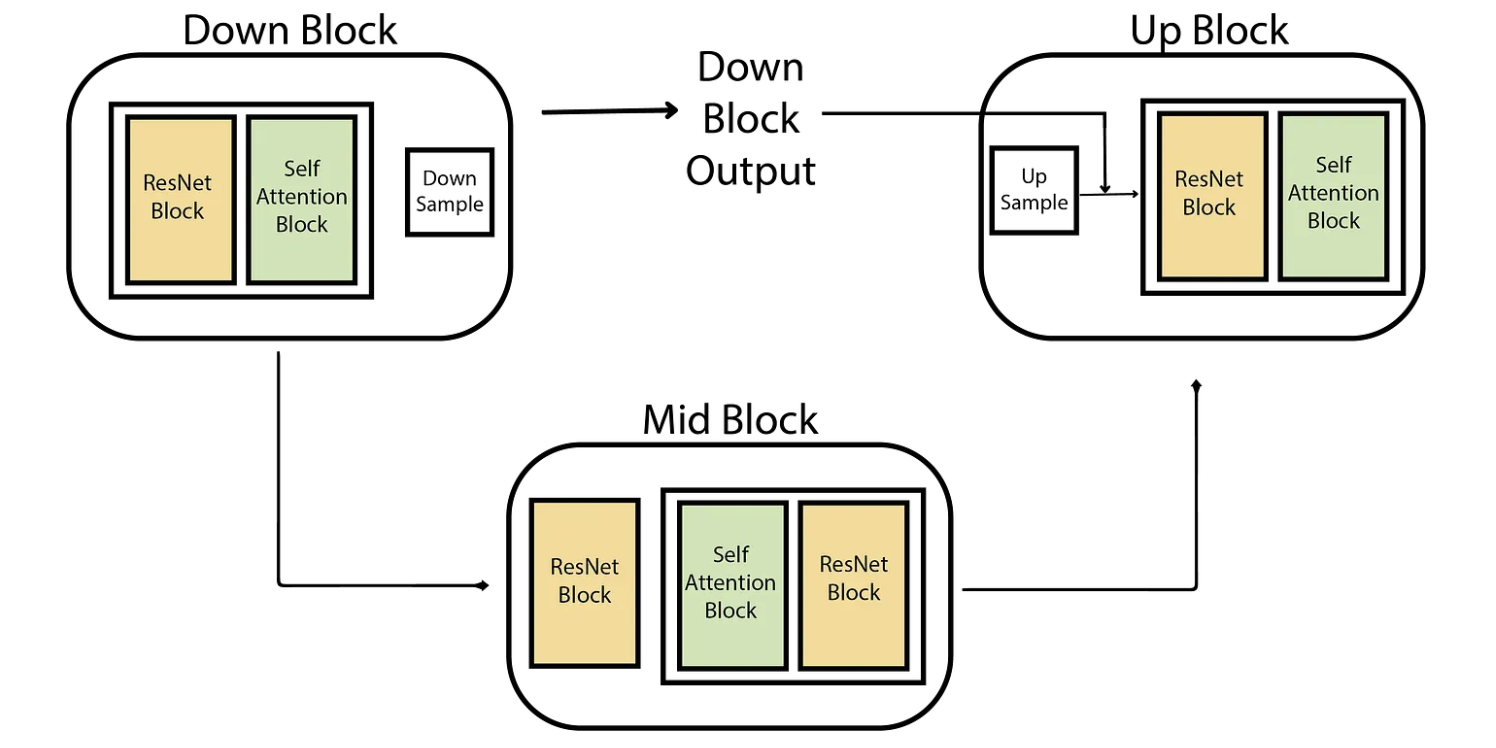

#### DownBlock

The `DownBlock` is a component of the U-Net used in the diffusion model. It processes the input feature maps using **ResNet blocks, self-attention layers, and optional downsampling**, while also incorporating **time step information**.

Encoder block that:
- Extracts features at different scales
- Incorporates time information
- Uses self-attention for long-range dependencies
- Reduces spatial resolution

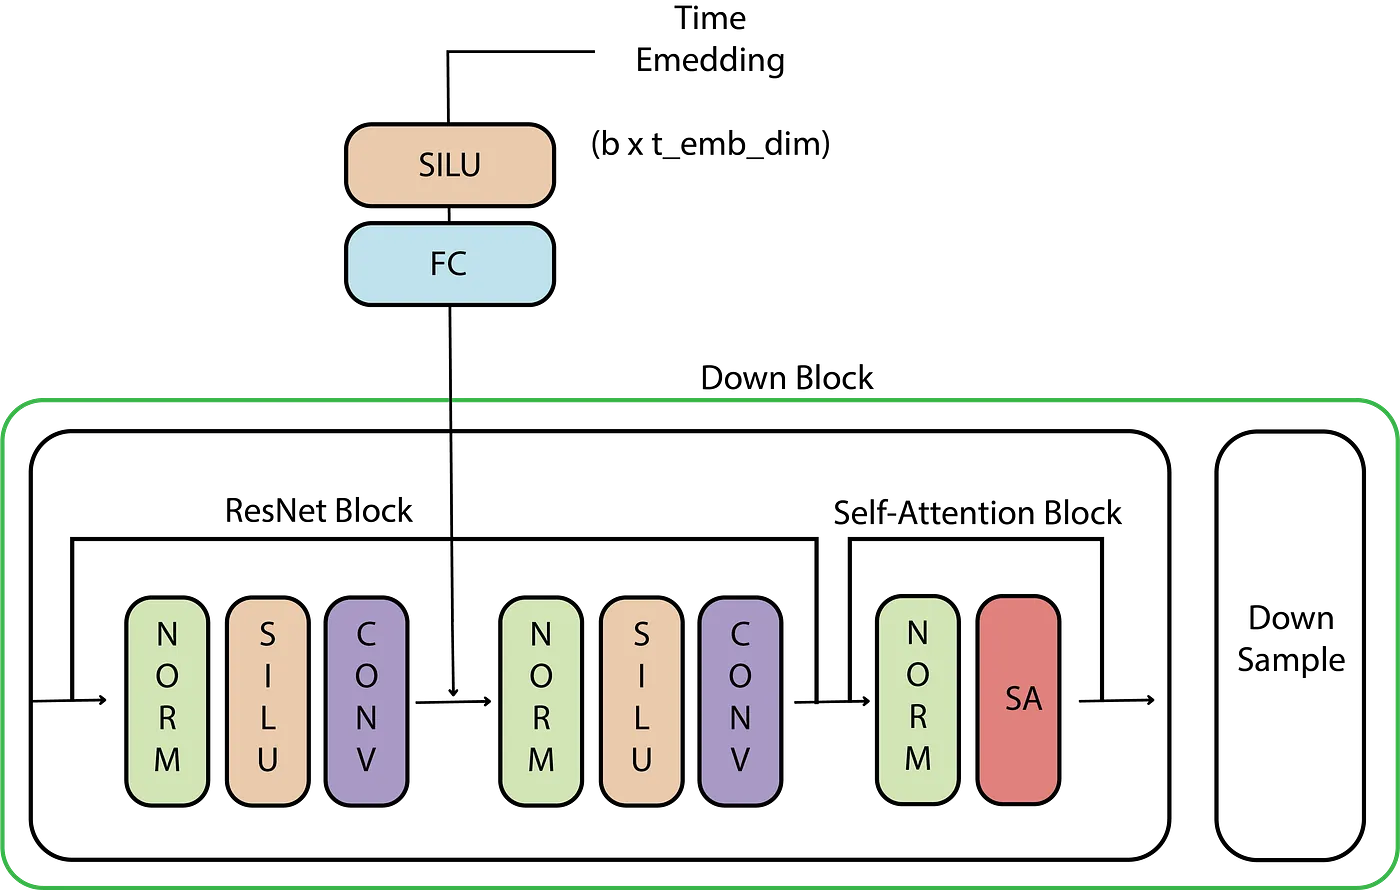

In [91]:
class DownBlock(nn.Module):

    def __init__(self, in_channels, out_channels, t_emb_dim,
                 down_sample=True, num_heads=4, num_layers=1):
        super().__init__()
        self.num_layers = num_layers
        self.down_sample = down_sample

        self.resnet_conv_first = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(8, in_channels if i == 0 else out_channels),
                    nn.SiLU(),
                    nn.Conv2d(in_channels if i == 0 else out_channels, out_channels,
                              kernel_size=3, stride=1, padding=1),
                )
                for i in range(num_layers)
            ]
        )

        self.t_emb_layers = nn.ModuleList([
            nn.Sequential(
                nn.SiLU(),
                nn.Linear(t_emb_dim, out_channels)
            )
            for _ in range(num_layers)
        ])

        self.resnet_conv_second = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(8, out_channels),
                    nn.SiLU(),
                    nn.Conv2d(out_channels, out_channels,
                              kernel_size=3, stride=1, padding=1),
                )
                for _ in range(num_layers)
            ]
        )

        self.attention_norms = nn.ModuleList(
            [nn.GroupNorm(8, out_channels) for _ in range(num_layers)]
        )

        self.attentions = nn.ModuleList(
            [nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
             for _ in range(num_layers)]
        )

        self.residual_input_conv = nn.ModuleList(
            [
                nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1)
                for i in range(num_layers)
            ]
        )

        self.down_sample_conv = nn.Conv2d(out_channels, out_channels,
                                          4, 2, 1) if self.down_sample else nn.Identity()

    def forward(self, x, t_emb):

        out = x

        for i in range(self.num_layers):
            resnet_input = out
            out = self.resnet_conv_first[i](out)
            out = out + self.t_emb_layers[i](t_emb)[:, :, None, None]  # Add time embedding
            out = self.resnet_conv_second[i](out)
            out = out + self.residual_input_conv[i](resnet_input)  # Residual connection

            batch_size, channels, h, w = out.shape
            in_attn = out.reshape(batch_size, channels, h * w)  # Flatten spatial dims
            in_attn = self.attention_norms[i](in_attn)
            in_attn = in_attn.transpose(1, 2)  # (B, H*W, C) for attention
            out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)  # Self-attention
            out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)  # Reshape back
            out = out + out_attn  # Residual connection

        out = self.down_sample_conv(out)
        return out

#### MidBlock

The MidBlock class is a module that sits in the middle of a U-Net architecture in a diffusion model. It consists of ResNet blocks and self-attention layers and integrates time embedding to handle temporal information. This is a crucial component of models used for tasks such as denoising diffusion.

Middle layer of U-Net that:
- Processes features at bottleneck resolution
- Captures global context
- Alternates between attention and ResNet blocks
- No downsampling/upsampling

In [92]:
class MidBlock(nn.Module):


    def __init__(self, in_channels, out_channels, t_emb_dim, num_heads=4, num_layers=1):
        super().__init__()
        self.num_layers = num_layers

        self.resnet_conv_first = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(8, in_channels if i == 0 else out_channels),
                    nn.SiLU(),
                    nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=3, stride=1,
                              padding=1),
                )
                for i in range(num_layers + 1)
            ]
        )

        self.t_emb_layers = nn.ModuleList([
            nn.Sequential(
                nn.SiLU(),
                nn.Linear(t_emb_dim, out_channels)
            )
            for _ in range(num_layers + 1)
        ])

        self.resnet_conv_second = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(8, out_channels),
                    nn.SiLU(),
                    nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
                )
                for _ in range(num_layers + 1)
            ]
        )

        self.attention_norms = nn.ModuleList(
            [nn.GroupNorm(8, out_channels) for _ in range(num_layers)]
        )

        self.attentions = nn.ModuleList(
            [nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
             for _ in range(num_layers)]
        )

        self.residual_input_conv = nn.ModuleList(
            [
                nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1)
                for i in range(num_layers + 1)
            ]
        )

    def forward(self, x, t_emb):

        out = x

        resnet_input = out
        out = self.resnet_conv_first[0](out)
        out = out + self.t_emb_layers[0](t_emb)[:, :, None, None]
        out = self.resnet_conv_second[0](out)
        out = out + self.residual_input_conv[0](resnet_input)

        for i in range(self.num_layers):
            batch_size, channels, h, w = out.shape
            in_attn = out.reshape(batch_size, channels, h * w)
            in_attn = self.attention_norms[i](in_attn)
            in_attn = in_attn.transpose(1, 2)
            out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
            out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
            out = out + out_attn

            resnet_input = out
            out = self.resnet_conv_first[i + 1](out)
            out = out + self.t_emb_layers[i + 1](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i + 1](out)
            out = out + self.residual_input_conv[i + 1](resnet_input)

        return out

#### UpBlock


The UpBlock class is part of the decoder stage of a U-Net-like architecture, typically used in diffusion models or other image generation/segmentation tasks. It combines up-sampling, skip connections, ResNet blocks, and self-attention to reconstruct the output image while preserving fine-grained details from earlier encoder stages.

Decoder block that:

- Upsamples spatial dimensions
- Concatenates with encoder skip connections
- Incorporates time information
- Uses self-attention for context

In [93]:
class UpBlock(nn.Module):

    def __init__(self, in_channels, out_channels, t_emb_dim, up_sample=True, num_heads=4, num_layers=1):
        super().__init__()
        self.num_layers = num_layers
        self.up_sample = up_sample

        self.resnet_conv_first = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(8, in_channels if i == 0 else out_channels),
                    nn.SiLU(),
                    nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=3, stride=1,
                              padding=1),
                )
                for i in range(num_layers)
            ]
        )

        self.t_emb_layers = nn.ModuleList([
            nn.Sequential(
                nn.SiLU(),
                nn.Linear(t_emb_dim, out_channels)
            )
            for _ in range(num_layers)
        ])

        self.resnet_conv_second = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(8, out_channels),
                    nn.SiLU(),
                    nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
                )
                for _ in range(num_layers)
            ]
        )

        self.attention_norms = nn.ModuleList(
            [nn.GroupNorm(8, out_channels) for _ in range(num_layers)]
        )

        self.attentions = nn.ModuleList(
            [nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
             for _ in range(num_layers)]
        )

        self.residual_input_conv = nn.ModuleList(
            [
                nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1)
                for i in range(num_layers)
            ]
        )

        self.up_sample_conv = nn.ConvTranspose2d(in_channels // 2, in_channels // 2,
                                                 4, 2, 1) if self.up_sample else nn.Identity()

    def forward(self, x, out_down, t_emb):
 
        x = self.up_sample_conv(x)

        x = torch.cat([x, out_down], dim=1)

        out = x
        for i in range(self.num_layers):
            resnet_input = out
            out = self.resnet_conv_first[i](out)
            out = out + self.t_emb_layers[i](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i](out)
            out = out + self.residual_input_conv[i](resnet_input)

            batch_size, channels, h, w = out.shape
            in_attn = out.reshape(batch_size, channels, h * w)
            in_attn = self.attention_norms[i](in_attn)
            in_attn = in_attn.transpose(1, 2)
            out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
            out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
            out = out + out_attn

        return out

#### Complete Unet Architecture

**What it does:**
- Complete encoder-decoder U-Net with:
  - Initial convolution
  - Multiple downsampling blocks (encoder)
  - Bottleneck (mid blocks)
  - Multiple upsampling blocks (decoder)
  - Final convolution to predict noise

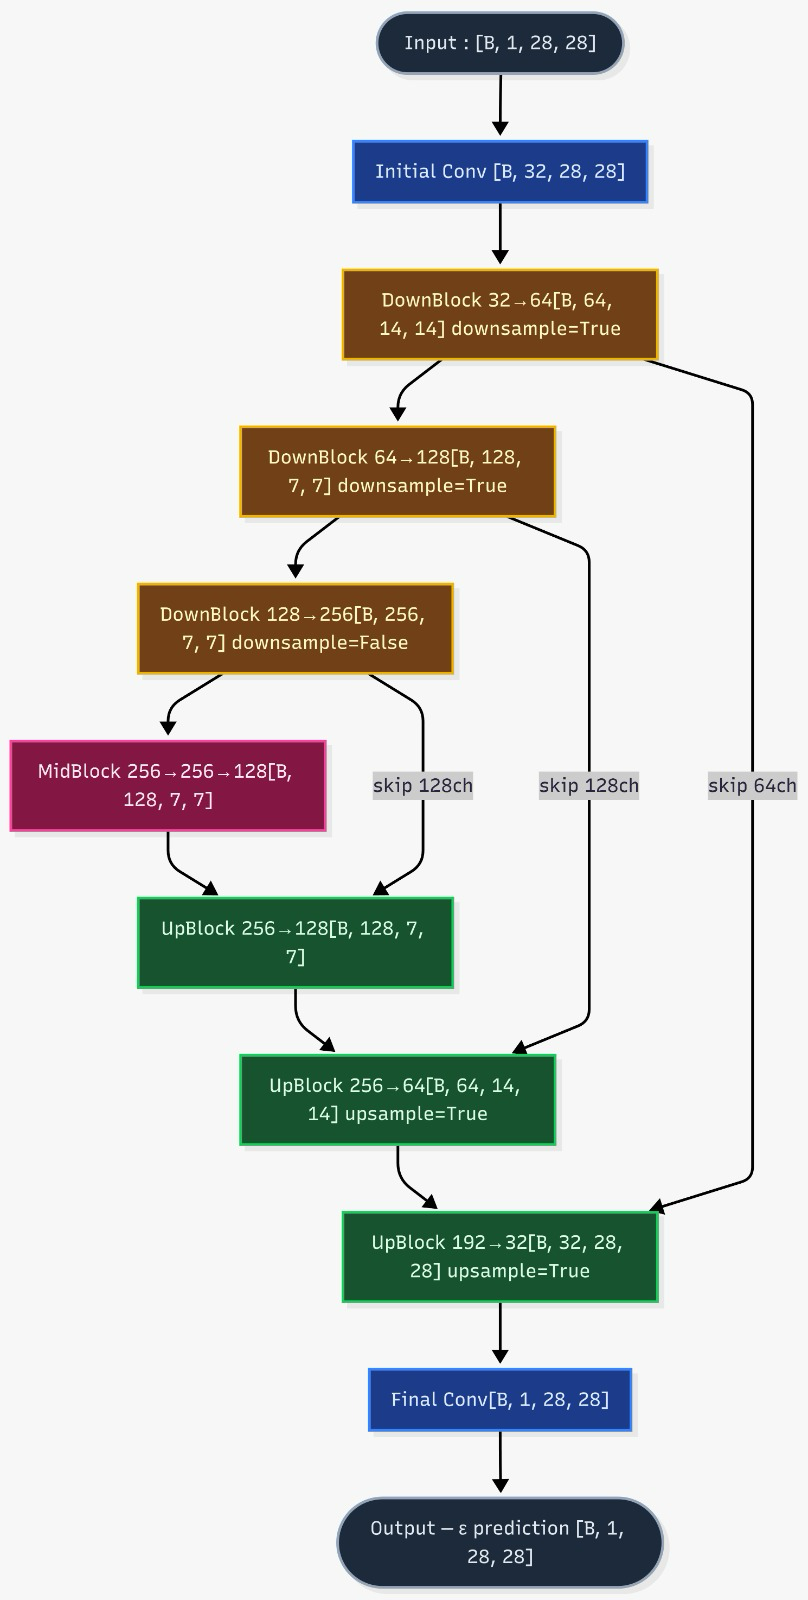

In [10]:
class Unet(nn.Module):


    def __init__(self, model_config):
        super().__init__()
        self.im_channels = model_config['im_channels']
        self.down_channels = model_config['down_channels']
        self.mid_channels = model_config['mid_channels']
        self.t_emb_dim = model_config['time_emb_dim']
        self.down_sample = model_config['down_sample']
        self.num_down_layers = model_config['num_down_layers']
        self.num_mid_layers = model_config['num_mid_layers']
        self.num_up_layers = model_config['num_up_layers']

        assert self.mid_channels[0] == self.down_channels[-1]
        assert self.mid_channels[-1] == self.down_channels[-2]
        assert len(self.down_sample) == len(self.down_channels) - 1

        self.t_proj = nn.Sequential(
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
            nn.SiLU(),
            nn.Linear(self.t_emb_dim, self.t_emb_dim)
        )

        self.up_sample = list(reversed(self.down_sample))

        self.conv_in = nn.Conv2d(self.im_channels, self.down_channels[0], kernel_size=3, padding=1)

        self.downs = nn.ModuleList([])
        for i in range(len(self.down_channels) - 1):
            self.downs.append(
                DownBlock(
                    self.down_channels[i],
                    self.down_channels[i + 1],
                    self.t_emb_dim,
                    down_sample=self.down_sample[i],
                    num_layers=self.num_down_layers
                )
            )

        self.mids = nn.ModuleList([])
        for i in range(len(self.mid_channels) - 1):
            self.mids.append(
                MidBlock(
                    self.mid_channels[i],
                    self.mid_channels[i + 1],
                    self.t_emb_dim,
                    num_layers=self.num_mid_layers
                )
            )

        self.ups = nn.ModuleList([])
        for i in reversed(range(len(self.down_channels) - 1)):
            self.ups.append(
                UpBlock(
                    self.down_channels[i] * 2,
                    self.down_channels[i - 1] if i != 0 else 16,
                    self.t_emb_dim,
                    up_sample=self.down_sample[i],
                    num_layers=self.num_up_layers
                )
            )

        self.norm_out = nn.GroupNorm(8, 16)
        self.conv_out = nn.Conv2d(16, self.im_channels, kernel_size=3, padding=1)

    def forward(self, x, t):

        out = self.conv_in(x)  # (B, C1, H, W)

        t_emb = get_time_embedding(torch.as_tensor(t).long(), self.t_emb_dim)
        t_emb = self.t_proj(t_emb)  # (B, t_emb_dim)

        down_outs = []
        for down in self.downs:
            down_outs.append(out)
            out = down(out, t_emb)

        for mid in self.mids:
            out = mid(out, t_emb)

        for up in self.ups:
            down_out = down_outs.pop()
            out = up(out, down_out, t_emb)

        out = self.norm_out(out)
        out = nn.SiLU()(out)
        out = self.conv_out(out)  # (B, C, H, W)

        return out

#### Loading the Dataset:

Dataset used: MNIST Dataset 

The dataset has been loaded into train_loader where it is split based on the given batch size and normalises to [-1,1] range.

In [94]:
class MNISTDataset(Dataset):

    def __init__(self, train=True):
        self.dataset = MNIST(
            root='./data',
            train=train,
            download=True,
            transform=transforms.ToTensor()
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, _ = self.dataset[idx]
        image = (2 * image) - 1
        return image

print("Loading MNIST dataset...")
mnist_dataset = MNISTDataset(train=True)
train_loader = DataLoader(
    mnist_dataset,
    batch_size=train_config['batch_size'],
    shuffle=True
)
print(f"Dataset size: {len(mnist_dataset)}")
print(f"Number of batches: {len(train_loader)}")

Loading MNIST dataset...
Dataset size: 60000
Number of batches: 938


#### Visualising the Dataset

**What it does:**
- Gets one batch of MNIST images
- Displays first 16 images in a 4×4 grid
- Shows what the training data looks like

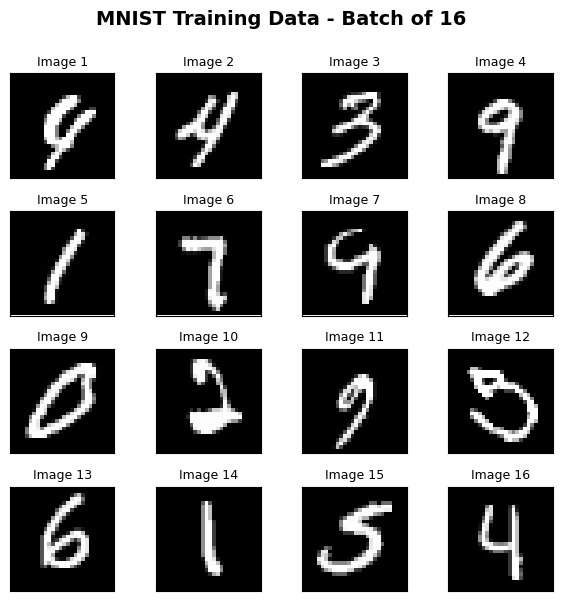

In [95]:
batch = next(iter(train_loader))
images = batch
num_images=16
title="MNIST Training Data - Batch of 16"

grid_size = int(np.sqrt(num_images))
fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))
fig.suptitle(title, fontsize=14, weight='bold', y=0.995)

for idx, ax in enumerate(axes.flat):
  if idx < num_images:
            img = images[idx].squeeze().cpu().numpy()
            img = (img + 1) / 2  
            img = np.clip(img, 0, 1)  

            ax.imshow(img, cmap='gray')
            ax.set_title(f'Image {idx+1}', fontsize=9)
  ax.set_xticks([])
  ax.set_yticks([])

plt.tight_layout()
plt.show()


#### Forward Diffusion Visualization

- Takes 4 clean MNIST images
- Adds noise progressively at different timesteps
- Visualizes the forward diffusion process
- Shows how much noise is added over time


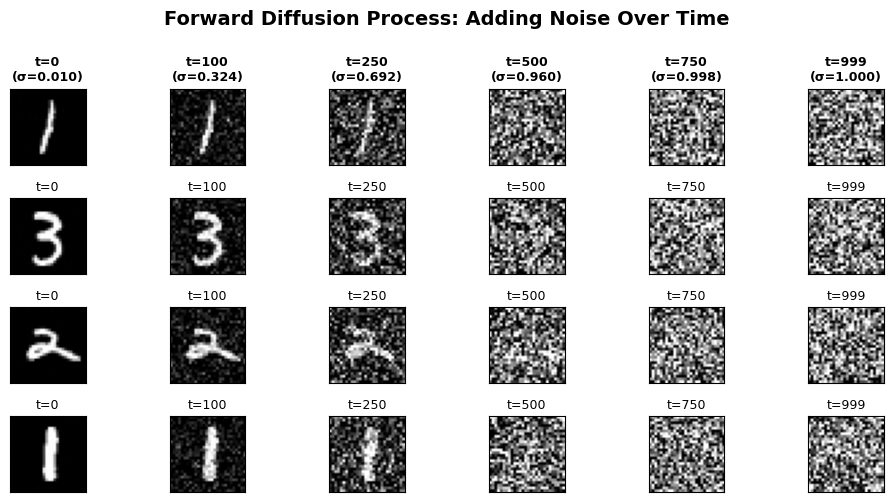


Forward Diffusion Visualization:
Images shown: 4 samples from the batch
Timesteps: [0, 100, 250, 500, 750, 999]
As t increases, more noise is added
σ values (noise std) shown in column headers


In [87]:
batch = next(iter(train_loader))
images = batch[:4]  
num_timesteps=[0, 100, 250, 500, 750, 999]
scheduler = LinearNoiseScheduler(
    num_timesteps=diffusion_config['num_timesteps'],
    beta_start=diffusion_config['beta_start'],
    beta_end=diffusion_config['beta_end']
)

num_samples = images.shape[0]
num_steps = len(num_timesteps)

fig, axes = plt.subplots(num_samples, num_steps, figsize=(10, 5))
fig.suptitle('Forward Diffusion Process: Adding Noise Over Time',
                fontsize=14, weight='bold', y=0.995)

for col_idx, t in enumerate(num_timesteps):
        t_tensor = torch.full((num_samples,), t, dtype=torch.long).to(device)

        noise = torch.randn_like(images)
        noisy_images = scheduler.add_noise(images, noise, t_tensor)

        for row_idx in range(num_samples):
            ax = axes[row_idx, col_idx]

            img = noisy_images[row_idx].squeeze().cpu().detach().numpy()
            img = (img + 1) / 2
            img = np.clip(img, 0, 1)

            ax.imshow(img, cmap='gray')

            if row_idx == 0:
                ax.set_title(f't={t}\n(σ={scheduler.sqrt_one_minus_alpha_cum_prod[t]:.3f})',
                           fontsize=9, weight='bold')
            else:
                ax.set_title(f't={t}', fontsize=9)

            ax.set_xticks([])
            ax.set_yticks([])

plt.tight_layout()
plt.show()

print(f"\nForward Diffusion Visualization:")
print(f"Images shown: 4 samples from the batch")
print(f"Timesteps: {num_timesteps}")
print(f"As t increases, more noise is added")
print(f"σ values (noise std) shown in column headers")


#### Configuration

**Model Config:**
- `down_channels = [32, 64, 128, 256]`: Channel progression for encoder
  - Layer 0: 32 channels (fine details)
  - Layer 1: 64 channels (medium features)
  - Layer 2: 128 channels (coarse features)
  - Layer 3: 256 channels (global context)

**Diffusion Config:**
- `num_timesteps = 1000`: Standard for DDPM
- `beta_start = 0.0001`: Almost no noise at first step
- `beta_end = 0.02`: Significant noise at final step

In [66]:
model_config = {
    'im_channels': 1,  
    'im_size': 28,    

    'down_channels': [32, 64, 128, 256],    
    'mid_channels': [256, 256, 128],         

    'down_sample': [True, True, False],      

    'time_emb_dim': 128,
    'num_down_layers': 2,
    'num_mid_layers': 2,
    'num_up_layers': 2,
}

diffusion_config = {
    'num_timesteps': 1000,
    'beta_start': 0.0001,
    'beta_end': 0.02,
}

train_config = {
    'batch_size': 64,
    'num_epochs': 25,  
    'lr': 0.0001,
    'num_samples': 16,
    'num_grid_rows': 4,
}

print("Configuration loaded")
print(f"Model config: {model_config}")
print(f"Diffusion config: {diffusion_config}")
print(f"Train config: {train_config}")

Configuration loaded
Model config: {'im_channels': 1, 'im_size': 28, 'down_channels': [32, 64, 128, 256], 'mid_channels': [256, 256, 128], 'down_sample': [True, True, False], 'time_emb_dim': 128, 'num_down_layers': 2, 'num_mid_layers': 2, 'num_up_layers': 2}
Diffusion config: {'num_timesteps': 1000, 'beta_start': 0.0001, 'beta_end': 0.02}
Train config: {'batch_size': 64, 'num_epochs': 25, 'lr': 0.0001, 'num_samples': 16, 'num_grid_rows': 4}


#### Training Loop


In [28]:
model2 = Unet(model_config).to(device)
scheduler = LinearNoiseScheduler(
    num_timesteps=diffusion_config['num_timesteps'],
    beta_start=diffusion_config['beta_start'],
    beta_end=diffusion_config['beta_end']
)
optimizer = Adam(model2.parameters(), lr=train_config['lr'])
criterion = nn.MSELoss()

total_params = sum(p.numel() for p in model2.parameters())
print(f"Model has {total_params:,} parameters")
print(f"Using device: {device}")
print(f"\nStarting training...")

model2.train()
all_losses = []

for epoch in range(train_config['num_epochs']):
    epoch_losses = []

    with tqdm(train_loader, desc=f"Epoch {epoch+1}/{train_config['num_epochs']}") as pbar:
        for images in pbar:
            images = images.to(device)

            batch_size = images.shape[0]
            t = torch.randint(0, diffusion_config['num_timesteps'], (batch_size,)).to(device)
            noise = torch.randn_like(images).to(device)

            noisy_images = scheduler.add_noise(images, noise, t)

            noise_pred = model2(noisy_images, t)

            loss = criterion(noise_pred, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            pbar.set_postfix({'loss': f"{np.mean(epoch_losses):.4f}"})

    avg_loss = np.mean(epoch_losses)
    all_losses.append(avg_loss)
    print(f"Epoch {epoch+1} - Average Loss: {avg_loss:.6f}")

print("\nTraining completed!")

Model has 10,188,081 parameters
Using device: cuda

Starting training...


Epoch 1/25: 100%|██████████| 938/938 [02:35<00:00,  6.05it/s, loss=0.1094]


Epoch 1 - Average Loss: 0.109397


Epoch 2/25: 100%|██████████| 938/938 [02:35<00:00,  6.05it/s, loss=0.0355]


Epoch 2 - Average Loss: 0.035515


...

Epoch 23 - Average Loss: 0.022731


Epoch 24/25: 100%|██████████| 938/938 [02:34<00:00,  6.06it/s, loss=0.0222]


Epoch 24 - Average Loss: 0.022182


Epoch 25/25: 100%|██████████| 938/938 [02:34<00:00,  6.05it/s, loss=0.0223]

Epoch 25 - Average Loss: 0.022296

Training completed!


#### Visualising the Loss

In [45]:
initial_loss = all_losses[0]
final_loss = all_losses[-1]
loss_reduction = ((initial_loss - final_loss) / initial_loss) * 100

In [89]:
import numpy as np
import torch

initial_loss = all_losses[0]
final_loss = all_losses[-1]
loss_reduction = ((initial_loss - final_loss) / initial_loss) * 100

loss_diffs = np.diff(all_losses)
improvements = np.sum(loss_diffs < 0)
stability = (improvements / len(all_losses)) * 100

max_improvement = all_losses[0] - min(all_losses)
target_loss = all_losses[0] - (0.9 * max_improvement)
convergence_epoch = next((i for i, l in enumerate(all_losses) if l <= target_loss), len(all_losses))

total_params = sum(p.numel() for p in model2.parameters())
model_size_mb = total_params * 4 / (1024**2)
conv_layers = sum(1 for m in model2.modules() if isinstance(m, torch.nn.Conv2d))
attention_layers = sum(1 for m in model2.modules() if isinstance(m, torch.nn.MultiheadAttention))

print(f"Initial Loss:              {initial_loss:.6f}")
print(f"Final Loss:                {final_loss:.6f}")
print(f"Loss Reduction:            {loss_reduction:.2f}%")
print(f"Training Stability:        {stability:.1f}%")
print(f"Convergence Epoch:         {convergence_epoch}/{len(all_losses)}")
print(f"Total Parameters:          {total_params:,}")
print(f"Model Size:                {model_size_mb:.2f} MB")


Initial Loss:              0.109397
Final Loss:                0.022296
Loss Reduction:            79.62%
Training Stability:        76.0%
Convergence Epoch:         3/25
Total Parameters:          10,188,081
Model Size:                38.86 MB


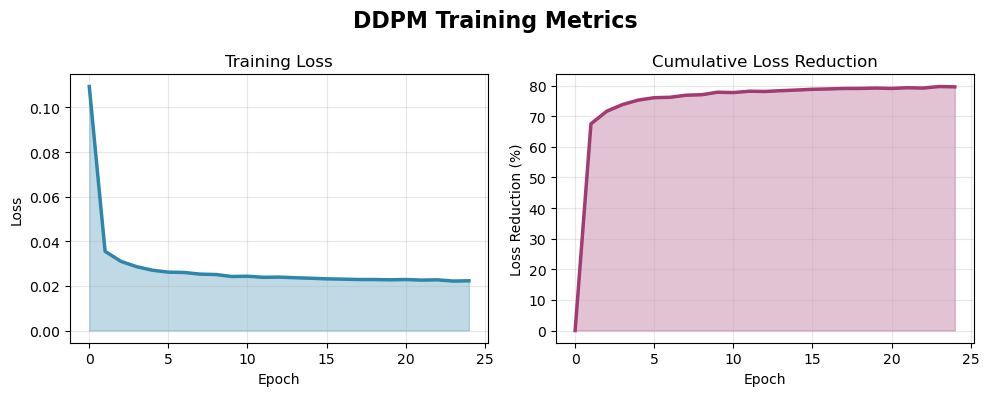

In [90]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('DDPM Training Metrics', fontsize=16, weight='bold')

axes[0].plot(all_losses, linewidth=2.5, color='#2E86AB')
axes[0].fill_between(range(len(all_losses)), all_losses, alpha=0.3, color='#2E86AB')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

loss_reduction_curve = [(all_losses[0] - l) / all_losses[0] * 100 for l in all_losses]
axes[1].plot(loss_reduction_curve, linewidth=2.5, color='#A23B72')
axes[1].fill_between(range(len(loss_reduction_curve)), loss_reduction_curve, alpha=0.3, color='#A23B72')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss Reduction (%)')
axes[1].set_title('Cumulative Loss Reduction')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


The model achieved a **79.62% loss reduction**, demonstrating strong learning and convergence. The initial loss of 0.109 represents the baseline random predictions, while the final loss of 0.022 indicates the model has effectively learned to predict noise at different denoising steps.

- Clear, recognizable generated digits
- Good diversity in generated images  
- Stable denoising across all 1000 timesteps
- High-quality image generation capability


#### Sampling and Generating image

- Generates new images from scratch
- Uses reverse diffusion process
- 1000 steps of iterative denoising



In [69]:
def sample_images(model, scheduler, num_samples, num_timesteps, im_channels, im_size):

    model.eval()

    xt = torch.randn(
        (num_samples, im_channels, im_size, im_size),
        device=device
    )

    generated_images = []

    with torch.no_grad():
        for i in tqdm(reversed(range(num_timesteps)), total=num_timesteps, desc="Sampling"):
            t = torch.full((num_samples,), i, device=device, dtype=torch.long)
            noise_pred = model(xt, t)

            xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, torch.tensor(i, device=device))

            if i % 50 == 0 or i == 0:
                generated_images.append(xt.clone().cpu())

    return xt.cpu(), generated_images



In [70]:
print("Generating images...")
generated, intermediate = sample_images(
    model2,
    scheduler,
    num_samples=train_config['num_samples'],
    num_timesteps=diffusion_config['num_timesteps'],
    im_channels=model_config['im_channels'],
    im_size=model_config['im_size']
)
print("Image generation completed!")

Generating images...


Sampling: 100%|██████████| 1000/1000 [00:16<00:00, 61.57it/s]

Image generation completed!


In [83]:
def plot_images(images, title="", num_images=16):

    grid_size = int(np.ceil(np.sqrt(num_images)))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(5, 5))

    images_normalized = (images[:num_images] + 1) / 2
    images_normalized = torch.clamp(images_normalized, 0, 1)

    axes = axes.flatten()

    for idx, ax in enumerate(axes):
        if idx < len(images_normalized):
            img = images_normalized[idx].squeeze().numpy()
            ax.imshow(img, cmap='gray')
        ax.axis('off')  

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    return fig



#### Generated images

- Grid of 16 generated digits
- Evolution of generation at different timesteps
- Shows quality improvement as denoising progresses


Generated images shape: torch.Size([16, 1, 28, 28])


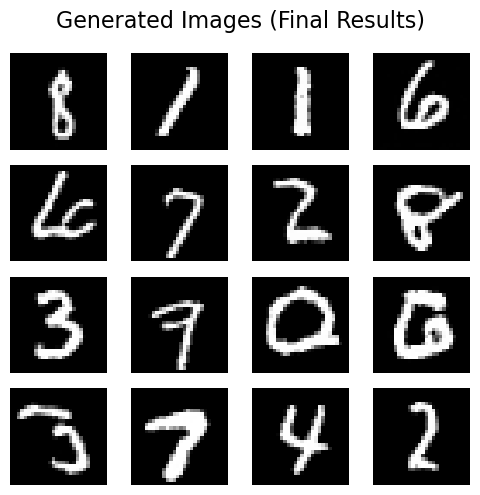


Generated images at different timesteps:


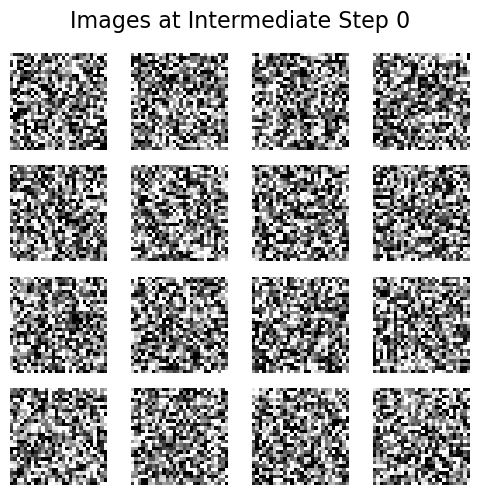

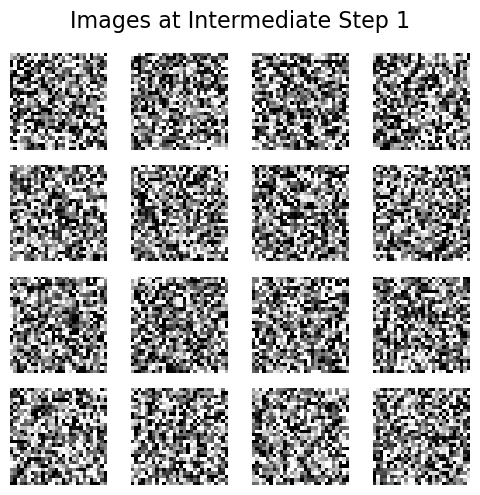

In [85]:
print(f"Generated images shape: {generated.shape}")
fig1 = plot_images(
    generated,
    title=f"Generated Images (Final Results)",
    num_images=min(16, train_config['num_samples'])
)
plt.show()

if len(intermediate) > 0:
    print(f"\nGenerated images at different timesteps:")
    for idx, imgs in enumerate(intermediate[:2]):  # Show first 3 snapshots
        fig = plot_images(
            imgs,
            title=f"Images at Intermediate Step {idx}",
            num_images=min(16, train_config['num_samples'])
        )
        plt.show()

In [34]:

print("\n" + "="*80)
print("MODEL COMPLEXITY METRICS")
print("="*80)

total_params = sum(p.numel() for p in model2.parameters())
trainable_params = sum(p.numel() for p in model2.parameters() if p.requires_grad)

model_size_mb = total_params * 4 / (1024**2)  # 4 bytes per float32

conv_layers = sum(1 for m in model2.modules() if isinstance(m, nn.Conv2d))
linear_layers = sum(1 for m in model2.modules() if isinstance(m, nn.Linear))
attention_layers = sum(1 for m in model2.modules() if isinstance(m, nn.MultiheadAttention))
norm_layers = sum(1 for m in model2.modules() if isinstance(m, nn.GroupNorm))

print(f"\nTotal Parameters:        {total_params:,}")
print(f"Trainable Parameters:    {trainable_params:,}")
print(f"Model Size (FP32):       {model_size_mb:.2f} MB")

print(f"\nLayer Breakdown:")
print(f"  Conv2d Layers:         {conv_layers}")
print(f"  Linear Layers:         {linear_layers}")
print(f"  Attention Layers:      {attention_layers}")
print(f"  GroupNorm Layers:      {norm_layers}")

print(f"\nEstimated Memory Usage (training):")
print(f"  Model Weights:         {model_size_mb:.2f} MB")
print(f"  Gradients:             {model_size_mb:.2f} MB")
print(f"  Optimizer State:       {model_size_mb * 2:.2f} MB (Adam)")
print(f"  Total (approx):        {model_size_mb * 5:.2f} MB")



MODEL COMPLEXITY METRICS

Total Parameters:        10,188,081
Trainable Parameters:    10,188,081
Model Size (FP32):       38.86 MB

Layer Breakdown:
  Conv2d Layers:         58
  Linear Layers:         36
  Attention Layers:      16
  GroupNorm Layers:      53

Estimated Memory Usage (training):
  Model Weights:         38.86 MB
  Gradients:             38.86 MB
  Optimizer State:       77.73 MB (Adam)
  Total (approx):        194.32 MB


#### FID Score Calculation

**Fréchet Inception Distance (FID)** score - Quantitative metric for image generation quality

1. Generate 500 images
2. Save real and generated images to folders
3. Use pre-trained Inception network to extract features
4. Compute FID statistic

**FID interpretation:**

| FID Score | Quality Level |
|-----------|---------------|
| < 10 | State-of-the-art |
| 10-30 | Excellent |
| 30-50 | Good |
| 50-100 | Fair |
| > 100 | Poor |

In [52]:
def calculate_fid(model, scheduler, real_loader, num_generated=500, device='cuda'):
    os.makedirs('./fid_real', exist_ok=True)
    os.makedirs('./fid_generated', exist_ok=True)
    
    # Save real images
    real_count = 0
    for batch in real_loader:
        for img in batch:
            if real_count >= num_generated:
                break
            img_norm = (img + 1) / 2
            save_image(img_norm, f'./fid_real/real_{real_count:05d}.png')
            real_count += 1
        if real_count >= num_generated:
            break
    
    model.eval()
    gen_count = 0
    with torch.no_grad():
        for i in range(0, num_generated, 16):
            batch_size = min(16, num_generated - i)
            gen, _ = sample_images(model, scheduler, batch_size, 1000, 1, 28)
            for img in gen:
                img_norm = (img + 1) / 2
                save_image(img_norm, f'./fid_generated/gen_{gen_count:05d}.png')
                gen_count += 1
    
    fid = calculate_fid_given_paths(['./fid_real', './fid_generated'], device=device,batch_size=50,dims=2048)
    print(f" FID Score: {fid:.4f}")
    return fid



In [53]:
fid_score = calculate_fid(model2, scheduler, train_loader, num_generated=500)

100%|██████████| 10/10 [00:00<00:00, 14.75it/s]


 FID Score: 21.9575


The model achieved an FID score of 21.96, which falls in the excellent range (10-30). This indicates high-quality image generation with good distribution matching to real MNIST data. The FID score validates the effectiveness of our DDPM implementation and confirms that the model has successfully learned to generate realistic handwritten digits.

#### Save Model Checkpoint

In [96]:
checkpoint_dir = './checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(checkpoint_dir, 'ddpm_model2.pth')
torch.save(model.state_dict(), checkpoint_path)
print(f"Model saved to {checkpoint_path}")


Model saved to ./checkpoints/ddpm_model2.pth


In [97]:
full_checkpoint_path = os.path.join(checkpoint_dir, 'ddpm2_full_checkpoint.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'model_config': model_config,
    'diffusion_config': diffusion_config,
    'train_losses': all_losses,
}, full_checkpoint_path)
print(f"Full checkpoint saved to {full_checkpoint_path}")

Full checkpoint saved to ./checkpoints/ddpm2_full_checkpoint.pth
